<a href="https://colab.research.google.com/github/Ashutos0762/Reservoir_MBE_Solvers/blob/main/MBE_project_case6.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.interpolate import interp1d

# Case 6: Estimate Average Reservoir Pressure from MBE
# Known: N, m (from previous analysis), PVT table
# Given: Production data (Np, Gp, Wp) — but NO pressure measurements
# Find: Average reservoir pressure at each time step

N = 15e6; m = 0.5; Boi = 1.450; Rsi = 800; Bgi = 0.00085; Bw = 1.0

pvt = pd.DataFrame({
    'P':  [4000, 3800, 3600, 3400, 3200, 3000, 2800, 2600, 2400, 2200, 2000],
    'Bo': [1.450, 1.430, 1.405, 1.375, 1.340, 1.300, 1.255, 1.205, 1.150, 1.090, 1.025],
    'Rs': [800, 760, 715, 665, 610, 550, 485, 415, 340, 260, 175],
    'Bg': [0.00085, 0.00090, 0.00096, 0.00103, 0.00112, 0.00123, 0.00137, 0.00155, 0.00178, 0.00210, 0.00255]
})

# Production data at 4 time steps (pressure unknown — that's what we're solving for)
prod = pd.DataFrame({
    'Time':    [1, 2, 3, 4],
    'Np_MSTB': [1200, 2800, 4800, 7200],
    'Gp_MMscf':[1740, 3610, 6360, 10000],
    'Wp_MSTB': [20, 60, 140, 280],
    'P_true':  [3500, 3100, 2700, 2300]   # for verification only
})

print("PVT Table:"); print(pvt.to_string(index=False))
print("\nProduction Data:"); print(prod.to_string(index=False))

PVT Table:
   P    Bo  Rs      Bg
4000 1.450 800 0.00085
3800 1.430 760 0.00090
3600 1.405 715 0.00096
3400 1.375 665 0.00103
3200 1.340 610 0.00112
3000 1.300 550 0.00123
2800 1.255 485 0.00137
2600 1.205 415 0.00155
2400 1.150 340 0.00178
2200 1.090 260 0.00210
2000 1.025 175 0.00255

Production Data:
 Time  Np_MSTB  Gp_MMscf  Wp_MSTB  P_true
    1     1200      1740       20    3500
    2     2800      3610       60    3100
    3     4800      6360      140    2700
    4     7200     10000      280    2300


In [ ]:
Bo_f = interp1d(pvt['P'], pvt['Bo'], kind='cubic', fill_value='extrapolate')
Rs_f = interp1d(pvt['P'], pvt['Rs'], kind='cubic', fill_value='extrapolate')
Bg_f = interp1d(pvt['P'], pvt['Bg'], kind='cubic', fill_value='extrapolate')

P_sweep = np.linspace(2000, 4000, 500)

def LHS(P, Np_stb, Rp, Wp_stb):
    """F computed from production data at assumed P"""
    return Np_stb * (Bo_f(P) + (Rp - Rs_f(P)) * Bg_f(P)) + Wp_stb * Bw

def RHS(P):
    """N(Eo + mEg) computed from known N, m at assumed P"""
    Bt = Bo_f(P) + (Rsi - Rs_f(P)) * Bg_f(P)
    Eo = Bt - Boi
    Eg = Boi * (Bg_f(P) / Bgi - 1)
    return N * (Eo + m * Eg)

print("Interpolation ready ✅")

Interpolation ready ✅


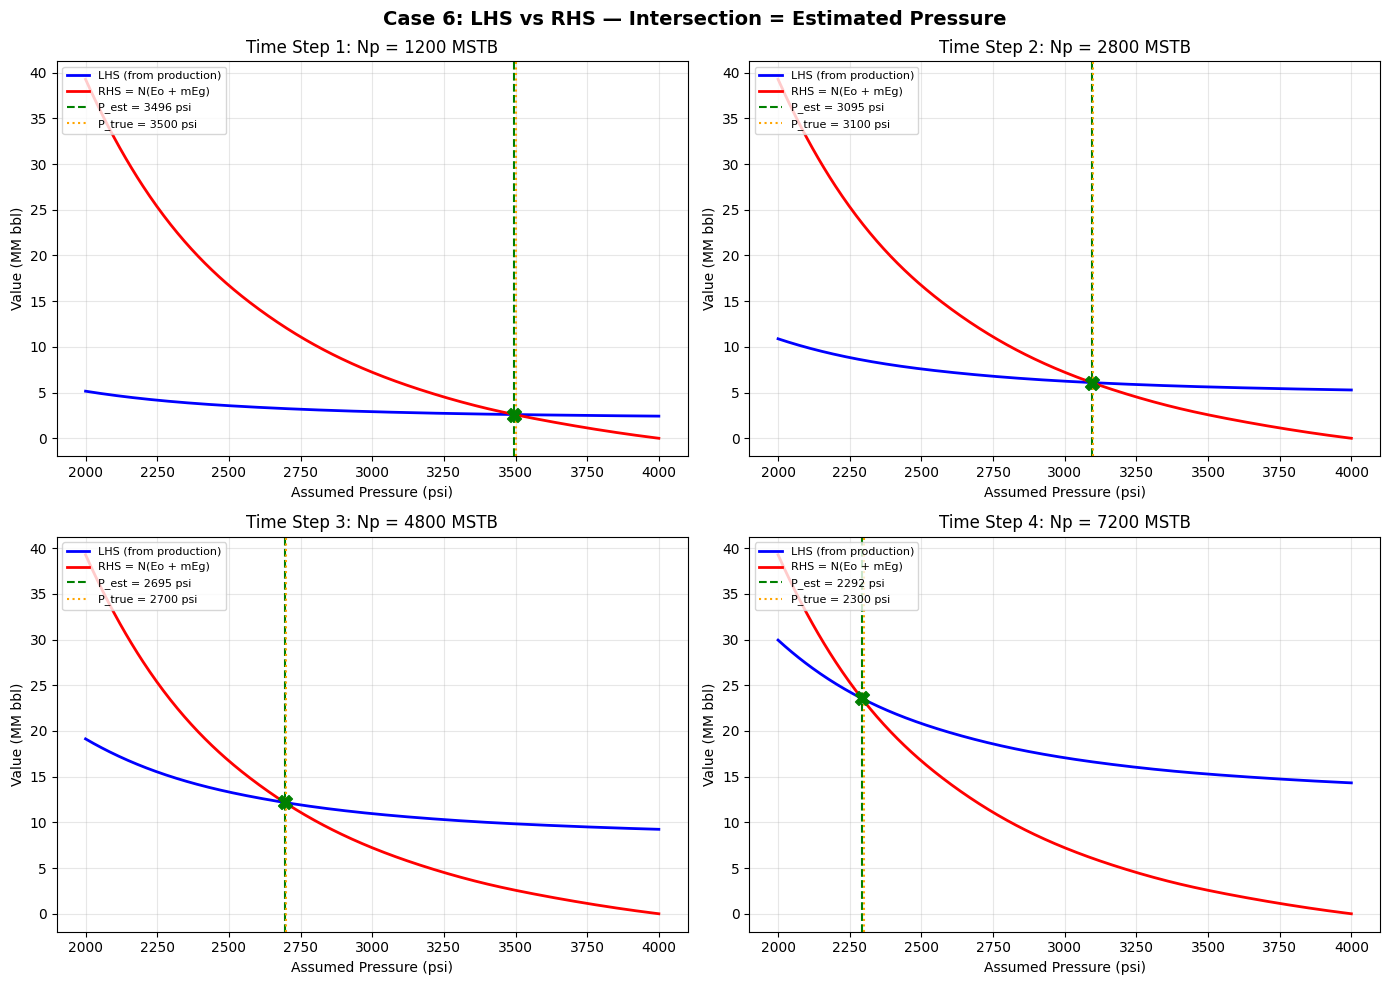

 Time  Np_MSTB  P_true  P_est  Error
    1     1200    3500 3496.0   -4.0
    2     2800    3100 3095.0   -5.0
    3     4800    2700 2695.0   -5.0
    4     7200    2300 2292.0   -8.0


In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
P_est = []

for i, row in prod.iterrows():
    ax = axes[i // 2][i % 2]

    Np_stb = row['Np_MSTB'] * 1e3
    Rp = row['Gp_MMscf'] * 1e6 / Np_stb
    Wp_stb = row['Wp_MSTB'] * 1e3

    lhs = LHS(P_sweep, Np_stb, Rp, Wp_stb)
    rhs = RHS(P_sweep)

    # Find intersection
    diff = lhs - rhs
    idx = np.where(np.diff(np.sign(diff)))[0]
    P_cross = P_sweep[idx[0]] + (P_sweep[idx[0]+1] - P_sweep[idx[0]]) * \
              abs(diff[idx[0]]) / (abs(diff[idx[0]]) + abs(diff[idx[0]+1]))
    P_est.append(P_cross)

    ax.plot(P_sweep, lhs / 1e6, 'b-', lw=2, label='LHS (from production)')
    ax.plot(P_sweep, rhs / 1e6, 'r-', lw=2, label='RHS = N(Eo + mEg)')
    ax.axvline(P_cross, color='green', ls='--', lw=1.5, label=f'P_est = {P_cross:.0f} psi')
    ax.axvline(row['P_true'], color='orange', ls=':', lw=1.5, label=f'P_true = {row["P_true"]} psi')
    ax.scatter([P_cross], [np.interp(P_cross, P_sweep, rhs/1e6)], c='green', s=100, zorder=5, marker='X')

    ax.set_xlabel('Assumed Pressure (psi)')
    ax.set_ylabel('Value (MM bbl)')
    ax.set_title(f'Time Step {row["Time"]}: Np = {row["Np_MSTB"]} MSTB')
    ax.legend(fontsize=8, loc='upper left')
    ax.grid(alpha=0.3)

plt.suptitle('Case 6: LHS vs RHS — Intersection = Estimated Pressure', fontweight='bold', fontsize=14)
plt.tight_layout()
plt.show()

prod['P_est'] = P_est
prod['Error'] = (prod['P_est'] - prod['P_true']).round(0)
print(prod[['Time', 'Np_MSTB', 'P_true', 'P_est', 'Error']].round(0).to_string(index=False))

In [ ]:
avg_err = prod['Error'].abs().mean()

print("=" * 55)
print("  CASE 6 SUMMARY")
print("  Average Reservoir Pressure Estimation")
print("  Method: LHS(P) vs RHS(P) intersection")
print("=" * 55)
print()
for _, row in prod.iterrows():
    print(f"  Time {row['Time']}: P_est = {row['P_est']:.0f} psi  "
          f"(true = {row['P_true']:.0f}, error = {row['Error']:+.0f} psi)")
print(f"\n  Avg absolute error: {avg_err:.0f} psi")
print()
print("  Takeaway:")
print("  - When pressure data is unavailable, MBE can estimate it")
print("  - Needs accurate N, m, and PVT properties")
print("  - LHS uses production data, RHS uses reservoir parameters")
print("  - Where they cross → average reservoir pressure")

  CASE 6 SUMMARY
  Average Reservoir Pressure Estimation
  Method: LHS(P) vs RHS(P) intersection

  Time 1.0: P_est = 3496 psi  (true = 3500, error = -4 psi)
  Time 2.0: P_est = 3095 psi  (true = 3100, error = -5 psi)
  Time 3.0: P_est = 2695 psi  (true = 2700, error = -5 psi)
  Time 4.0: P_est = 2292 psi  (true = 2300, error = -8 psi)

  Avg absolute error: 6 psi

  Takeaway:
  - When pressure data is unavailable, MBE can estimate it
  - Needs accurate N, m, and PVT properties
  - LHS uses production data, RHS uses reservoir parameters
  - Where they cross → average reservoir pressure
